In [18]:
import sys, pickle
import pandas as pd
import pandas.core.indexes
sys.modules['pandas.indexes'] = pandas.core.indexes   # 옛 경로 → 새 경로 통역

with open('data/LSWMD.pkl', 'rb') as f:
    df = pickle.load(f, encoding='latin1')

import os
print("작업 폴더:", os.getcwd())
print("크기:", df.shape)
df.head()

작업 폴더: /Users/yunseongchan/projects/semiconductor-ai
크기: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [19]:
# 한 칸이 실제로 어떻게 생겼나
sample = df['failureType'].iloc[0]
print("타입:", type(sample))
print("내용:", repr(sample))

타입: <class 'numpy.ndarray'>
내용: array([['none']], dtype='<U4')


In [20]:
import numpy as np

def extract_label(x):
    if isinstance(x, np.ndarray) and x.size > 0:
        return x.ravel()[0]   # 차원 상관없이 펴서 첫 글자
    return np.nan

df['failure'] = df['failureType'].apply(extract_label)
df['failure'].value_counts(dropna=False)


failure
NaN          638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

In [21]:
# (가) 라벨 달린 것 전부 (none 포함, 9개 클래스) — 학습 기본 대상
labeled = df.dropna(subset=['failure']).copy()
print("라벨 있는 웨이퍼:", len(labeled))      # 172,950 근처

# (나) 실제 결함 패턴만 (none 제외, 8개 클래스)
defects = labeled[labeled['failure'] != 'none'].copy()
print("실제 결함만:", len(defects))            # 25,519 근처

라벨 있는 웨이퍼: 172950
실제 결함만: 25519


In [22]:
# 결함 있는 웨이퍼 한 장의 속모습
wmap = defects['waferMap'].iloc[0]
print("타입:", type(wmap))
print("모양(shape):", wmap.shape)
print("들어있는 값들:", np.unique(wmap))

타입: <class 'numpy.ndarray'>
모양(shape): (45, 48)
들어있는 값들: [0 1 2]


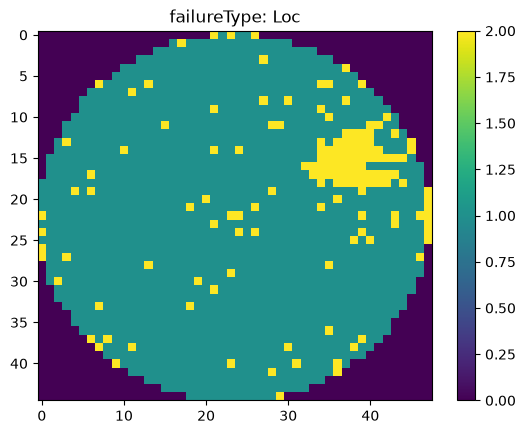

In [23]:
import matplotlib.pyplot as plt

wmap = defects['waferMap'].iloc[0]
label = defects['failure'].iloc[0]

plt.imshow(wmap)            # 2차원 숫자 격자를 색칠된 이미지로
plt.title(f"failureType: {label}")
plt.colorbar()             # 어떤 숫자가 어떤 색인지 범례
plt.show()

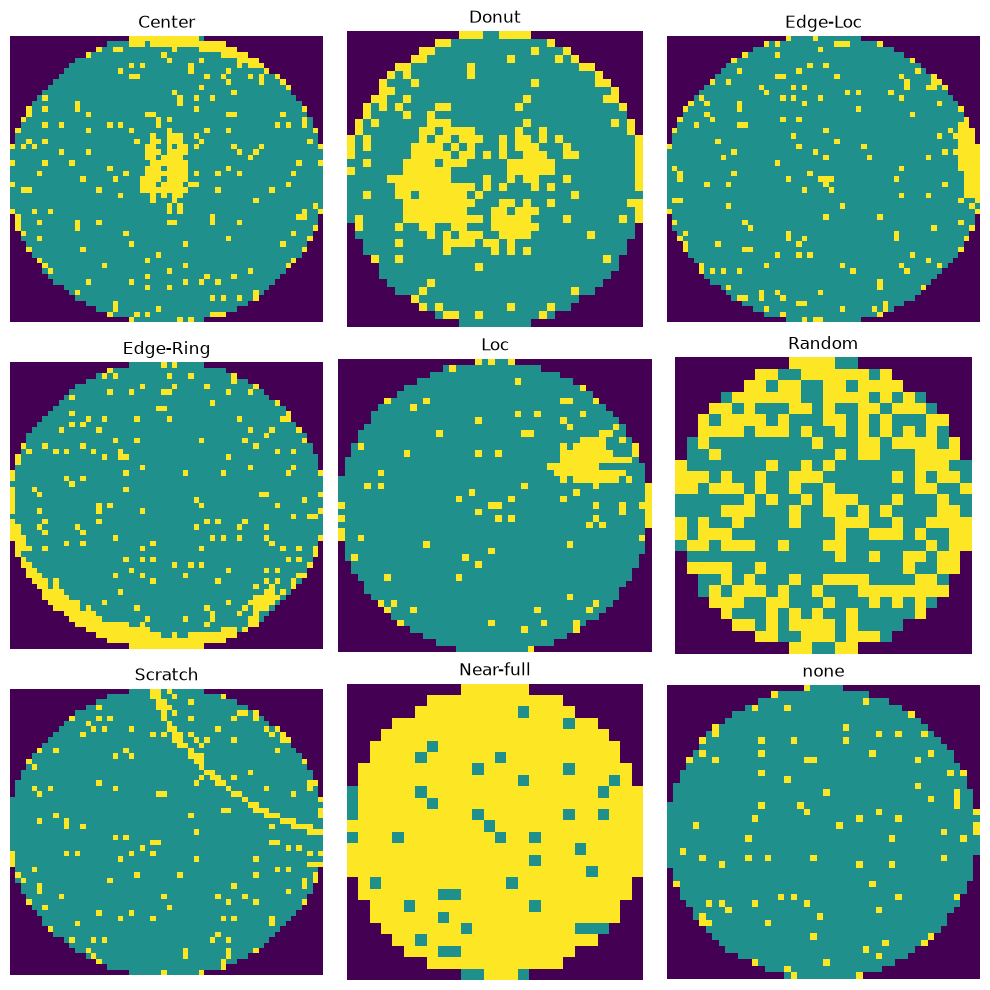

In [24]:
import matplotlib.pyplot as plt

types = ['Center','Donut','Edge-Loc','Edge-Ring',
         'Loc','Random','Scratch','Near-full','none']

fig, axes = plt.subplots(3, 3, figsize=(10, 10))   # 9칸 앨범 페이지

for ax, t in zip(axes.ravel(), types):
    wmap = labeled[labeled['failure'] == t]['waferMap'].iloc[0]  # 그 타입 첫 장
    ax.imshow(wmap)
    ax.set_title(t)
    ax.axis('off')        # 숫자 눈금 숨기기 (깔끔하게)

plt.tight_layout()        # 제목끼리 겹치지 않게 간격 정리
plt.show()


In [25]:
# 라벨 달린 것만 빠른 파일로 저장
labeled.to_pickle('data/wafer_labeled.pkl')
print("저장 완료! 행 수:", len(labeled))

저장 완료! 행 수: 172950


In [26]:
import pandas as pd
df = pd.read_pickle('data/wafer_labeled.pkl')   # 호환 처리 불필요, 빠름
print(df.shape)   # (172950, 7) 정도 — failure 열 포함

(172950, 7)


In [27]:
import pandas as pd
df = pd.read_pickle('data/wafer_labeled.pkl')
print(df.shape)   # (172950, 7) 나오면 준비 완료


(172950, 7)


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['failure'])

# 글자 ↔ 숫자 짝이 어떻게 매겨졌는지 확인
for i, name in enumerate(le.classes_):
    print(i, "→", name)

0 → Center
1 → Donut
2 → Edge-Loc
3 → Edge-Ring
4 → Loc
5 → Near-full
6 → Random
7 → Scratch
8 → none


In [29]:
# failure(글자)와 label(숫자)이 잘 짝지어졌는지
df[['failure', 'label']].drop_duplicates().sort_values('label')

,failure,label
44,Center,0
7316,Donut,1
36,Edge-Loc,2
100,Edge-Ring,3
19,Loc,4
929,Near-full,5
602,Random,6
134,Scratch,7
0,none,8


In [30]:
import pandas as pd
df = pd.read_pickle('data/wafer_labeled.pkl')

# 맵 크기가 정말 제각각인지 확인
sizes = df['waferMap'].apply(lambda x: x.shape)
print(sizes.value_counts().head(10))

waferMap
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
(39, 37)    10173
(33, 29)     8125
(42, 44)     6724
(44, 41)     6134
(41, 33)     5091
Name: count, dtype: int64


원래 크기: (45, 48)
바뀐 크기: (64, 64)


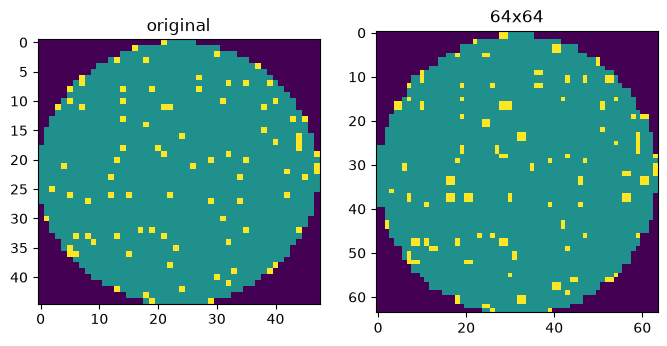

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

wmap = df['waferMap'].iloc[0]
print("원래 크기:", wmap.shape)

# 64x64로 크기 통일
resized = cv2.resize(wmap.astype(np.uint8), (64, 64),
                     interpolation=cv2.INTER_NEAREST)
print("바뀐 크기:", resized.shape)

# 원본 vs resize 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(wmap);    ax1.set_title("original")
ax2.imshow(resized); ax2.set_title("64x64")
plt.show()

In [32]:
def resize_wafer(x):
    return cv2.resize(x.astype(np.uint8), (64, 64),
                      interpolation=cv2.INTER_NEAREST)

df['wafer_resized'] = df['waferMap'].apply(resize_wafer)

# 전부 64x64로 통일됐는지 확인
print(df['wafer_resized'].apply(lambda x: x.shape).value_counts())

wafer_resized
(64, 64)    172950
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

X = df['wafer_resized']
y = df['label']

# 1차: 전체를 train(70%) vs 임시(30%)로
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

# 2차: 임시(30%)를 val(15%) vs test(15%)로 반씩
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("train:", len(X_train))
print("val:  ", len(X_val))
print("test: ", len(X_test))

KeyError: 'label'

In [ ]:
print("=== train 비율 ===")
print(y_train.value_counts(normalize=True).sort_index())
print("\n=== test 비율 ===")
print(y_test.value_counts(normalize=True).sort_index())

=== train 비율 ===
label
0    0.024830
1    0.003213
2    0.030000
3    0.055970
4    0.020774
5    0.000859
6    0.005006
7    0.006897
8    0.852451
Name: proportion, dtype: float64

=== test 비율 ===
label
0    0.024824
1    0.003199
2    0.030027
3    0.055969
4    0.020776
5    0.000848
6    0.005011
7    0.006900
8    0.852446
Name: proportion, dtype: float64


In [ ]:
import torch
print(torch.__version__)

2.12.0


In [ ]:
print(len(X_train), len(X_val), len(X_test))

121065 25942 25943


In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

class WaferDataset(Dataset):
    def __init__(self, X, y):
        # X: 웨이퍼 이미지들, y: 정답 라벨들 (창고에 재료 넣어두기)
        self.X = X.reset_index(drop=True)
        self.y = y.reset_index(drop=True)

    def __len__(self):
        # 창고에 재료가 몇 개 있나
        return len(self.X)

    def __getitem__(self, idx):
        # idx번째 재료 하나를 꺼내 모델이 먹을 형태(텐서)로 변환
        image = self.X[idx]                      # 64x64 numpy 배열
        label = self.y[idx]                      # 정답 숫자

        # (64,64) → (1,64,64) : 맨 앞에 '채널' 칸 하나 추가
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label, dtype=torch.long)
        return image, label

In [ ]:
train_ds = WaferDataset(X_train, y_train)
val_ds   = WaferDataset(X_val, y_val)
test_ds  = WaferDataset(X_test, y_test)

print("train 창고 크기:", len(train_ds))

# 0번째 하나 꺼내보기
img, lbl = train_ds[0]
print("이미지 모양:", img.shape)   # torch.Size([1, 64, 64]) 기대
print("정답 라벨:", lbl)

train 창고 크기: 121065
이미지 모양: torch.Size([1, 64, 64])
정답 라벨: tensor(8)


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print("train 배치 수:", len(train_loader))

train 배치 수: 1892


In [ ]:
images, labels = next(iter(train_loader))
print("이미지 배치 모양:", images.shape)   # [64, 1, 64, 64] 기대
print("라벨 배치 모양:", labels.shape)     # [64] 기대

이미지 배치 모양: torch.Size([64, 1, 64, 64])
라벨 배치 모양: torch.Size([64])


In [ ]:
import torch.nn as nn
from torchvision import models

# 1) ResNet18 설계도 가져오기 (가중치 없이 구조만)
model = models.resnet18(weights=None)

# 2) 입구 수선: 3채널 → 1채널 (흑백)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# 3) 출구 수선: 1000종류 → 9종류
model.fc = nn.Linear(model.fc.in_features, 9)

print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
images, labels = next(iter(train_loader))   # 64장 묶음 하나
outputs = model(images)                      # 모델에 통과
print("출력 모양:", outputs.shape)           # [64, 9] 기대

출력 모양: torch.Size([64, 9])


In [ ]:
import torch.nn as nn
import torch.optim as optim

# 맥(애플 실리콘)이면 GPU 가속(mps), 아니면 CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
print("사용 장치:", device)

criterion = nn.CrossEntropyLoss()              # 빗나간 정도 재는 자
optimizer = optim.Adam(model.parameters(), lr=0.001)   # 교정 코치

사용 장치: mps


In [ ]:
EPOCHS = 5   # 전체 데이터를 5번 반복 학습

for epoch in range(EPOCHS):
    model.train()              # "지금 공부 중" 모드로
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:        # 컨베이어에서 64장씩
        images = images.to(device)             # 데이터도 같은 장치(mps)로
        labels = labels.to(device)

        optimizer.zero_grad()                  # 이전 교정 기록 초기화

        outputs = model(images)                # ① 예측 (활 쏘기)
        loss = criterion(outputs, labels)      # ② 틀린 양 측정 (빗나감 재기)

        loss.backward()                        # ③ 고칠 방향 계산 (자동 미분)
        optimizer.step()                       # ④ 교정 (자세 수정)

        # --- 통계 집계 ---
        running_loss += loss.item()
        _, predicted = outputs.max(1)          # 9점수 중 가장 높은 걸 예측으로
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS}  loss: {epoch_loss:.4f}  정확도: {epoch_acc:.2f}%")

Epoch 1/5  loss: 0.1638  정확도: 95.09%
Epoch 2/5  loss: 0.1141  정확도: 96.29%
Epoch 3/5  loss: 0.0973  정확도: 96.76%
Epoch 4/5  loss: 0.0837  정확도: 97.12%
Epoch 5/5  loss: 0.0713  정확도: 97.49%


In [ ]:
model.eval()                    # 시험 모드로 전환
correct = 0
total = 0

with torch.no_grad():           # 교정 계산 끄기 (채점만)
    for images, labels in test_loader:    # 숨겨뒀던 test 데이터
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)           # 예측만
        _, predicted = outputs.max(1)     # 9점수 중 1등을 답으로
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test 정확도: {test_acc:.2f}%")

Test 정확도: 96.98%


/Users/yunseongchan/projects/semiconductor-ai/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yunseongchan/projects/semiconductor-ai/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yunseongchan/projects/semiconductor-ai/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yunseongchan/projects/semiconductor-ai/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


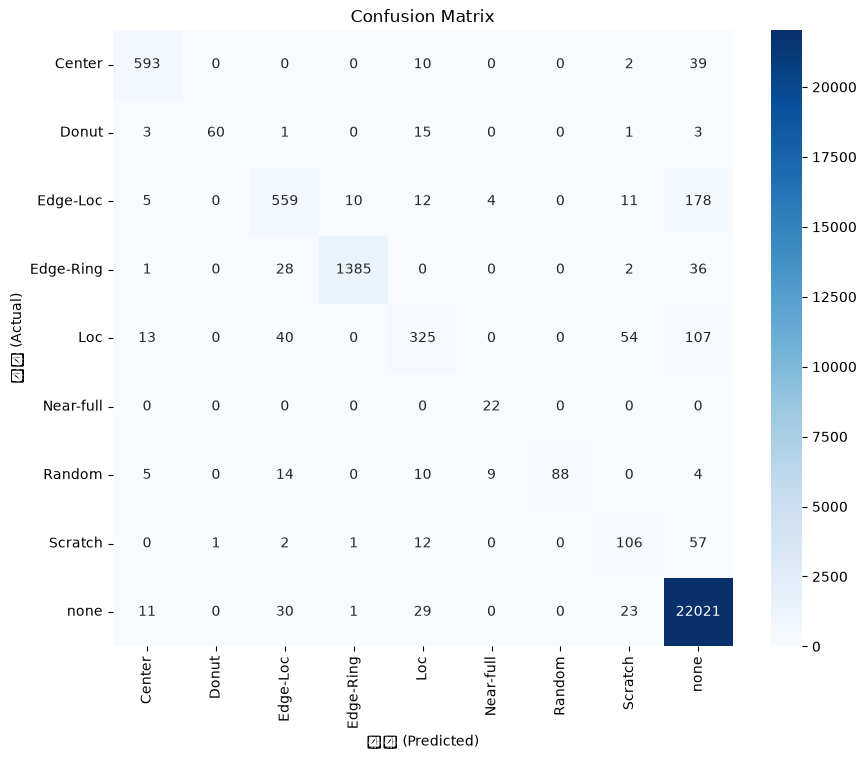

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# test 전체의 예측과 정답 모으기
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())    # 예측 모으기
        all_labels.extend(labels.numpy())            # 정답 모으기

# 혼동 행렬 그리기
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('예측 (Predicted)')
plt.ylabel('실제 (Actual)')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds,
                            target_names=le.classes_))

              precision    recall  f1-score   support

      Center       0.94      0.92      0.93       644
       Donut       0.98      0.72      0.83        83
    Edge-Loc       0.83      0.72      0.77       779
   Edge-Ring       0.99      0.95      0.97      1452
         Loc       0.79      0.60      0.68       539
   Near-full       0.63      1.00      0.77        22
      Random       1.00      0.68      0.81       130
     Scratch       0.53      0.59      0.56       179
        none       0.98      1.00      0.99     22115

    accuracy                           0.97     25943
   macro avg       0.85      0.80      0.81     25943
weighted avg       0.97      0.97      0.97     25943



In [ ]:
torch.save(model.state_dict(), 'resnet18_wafer.pth')
print("모델 저장 완료")

모델 저장 완료


In [ ]:
print("데이터:", df.shape)
print("train 배치 수:", len(train_loader))
print("클래스:", le.classes_)

데이터: (172950, 9)
train 배치 수: 1892
클래스: [np.str_('Center') np.str_('Donut') np.str_('Edge-Loc')
 np.str_('Edge-Ring') np.str_('Loc') np.str_('Near-full')
 np.str_('Random') np.str_('Scratch') np.str_('none')]


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(9)                    # 0~8
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train.values
)

print("클래스별 가중치:")
for i, w in enumerate(weights):
    print(f"  {le.classes_[i]:12s}: {w:.3f}")

weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

클래스별 가중치:
  Center      : 4.475
  Donut       : 34.580
  Edge-Loc    : 3.704
  Edge-Ring   : 1.985
  Loc         : 5.349
  Near-full   : 129.343
  Random      : 22.197
  Scratch     : 16.110
  none        : 0.130


NameError: name 'device' is not defined

In [ ]:
import torch
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("사용 장치:", device)

사용 장치: mps


In [ ]:
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
print(weights_tensor)

tensor([  4.4749,  34.5801,   3.7037,   1.9852,   5.3486, 129.3429,  22.1975,
         16.1098,   0.1303], device='mps:0')


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 모델 새로 준비 (백지상태 — 공정 비교 위해)
model_weighted = models.resnet18(weights=None)
model_weighted.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model_weighted.fc = nn.Linear(model_weighted.fc.in_features, 9)
model_weighted = model_weighted.to(device)

# 핵심: 손실 함수에 class weight 끼우기
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model_weighted.parameters(), lr=0.001)

print("가중치 적용 모델 준비 완료")

가중치 적용 모델 준비 완료


In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model_weighted.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_weighted(images)        # ① 예측
        loss = criterion(outputs, labels)       # ② 틀린 양 (가중치 적용됨)
        loss.backward()                         # ③ 고칠 방향
        optimizer.step()                        # ④ 교정

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS}  loss: {epoch_loss:.4f}  정확도: {epoch_acc:.2f}%")

Epoch 1/5  loss: 0.8639  정확도: 70.80%
Epoch 2/5  loss: 0.5600  정확도: 81.54%
Epoch 3/5  loss: 0.4884  정확도: 83.15%
Epoch 4/5  loss: 0.4165  정확도: 86.49%
Epoch 5/5  loss: 0.3644  정확도: 87.72%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 개선 후 모델로 test 예측 모으기
all_preds_w = []
all_labels_w = []

model_weighted.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_weighted(images)
        _, predicted = outputs.max(1)
        all_preds_w.extend(predicted.cpu().numpy())
        all_labels_w.extend(labels.numpy())

# 성적표 출력
print("=== 개선 후 (class weight 적용) ===")
print(classification_report(all_labels_w, all_preds_w,
                            target_names=le.classes_))

=== 개선 후 (class weight 적용) ===
              precision    recall  f1-score   support

      Center       0.71      0.91      0.80       644
       Donut       0.54      0.95      0.69        83
    Edge-Loc       0.31      0.84      0.45       779
   Edge-Ring       0.91      0.97      0.94      1452
         Loc       0.52      0.66      0.58       539
   Near-full       0.78      0.82      0.80        22
      Random       0.36      0.95      0.53       130
     Scratch       0.05      0.68      0.09       179
        none       1.00      0.80      0.89     22115

    accuracy                           0.81     25943
   macro avg       0.58      0.84      0.64     25943
weighted avg       0.94      0.81      0.86     25943



In [ ]:
import numpy as np

# 기존 balanced 가중치에 제곱근을 씌워 완화
weights_soft = np.sqrt(weights)

print("가중치 비교 (원래 → 완화):")
for i in range(9):
    print(f"  {le.classes_[i]:12s}: {weights[i]:6.2f} → {weights_soft[i]:.2f}")

weights_soft_tensor = torch.tensor(weights_soft, dtype=torch.float32).to(device)

가중치 비교 (원래 → 완화):
  Center      :   4.47 → 2.12
  Donut       :  34.58 → 5.88
  Edge-Loc    :   3.70 → 1.92
  Edge-Ring   :   1.99 → 1.41
  Loc         :   5.35 → 2.31
  Near-full   : 129.34 → 11.37
  Random      :  22.20 → 4.71
  Scratch     :  16.11 → 4.01
  none        :   0.13 → 0.36


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 백지 모델 새로 준비
model_soft = models.resnet18(weights=None)
model_soft.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model_soft.fc = nn.Linear(model_soft.fc.in_features, 9)
model_soft = model_soft.to(device)

# 완화된 가중치로 손실 함수
criterion = nn.CrossEntropyLoss(weight=weights_soft_tensor)
optimizer = optim.Adam(model_soft.parameters(), lr=0.001)

# 학습 루프 (양궁 4단계, 동일)
EPOCHS = 5
for epoch in range(EPOCHS):
    model_soft.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model_soft(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS}  loss: {epoch_loss:.4f}  정확도: {epoch_acc:.2f}%")

Epoch 1/5  loss: 0.4972  정확도: 92.79%
Epoch 2/5  loss: 0.3349  정확도: 94.49%
Epoch 3/5  loss: 0.2818  정확도: 95.05%
Epoch 4/5  loss: 0.2369  정확도: 95.56%
Epoch 5/5  loss: 0.1992  정확도: 96.03%


In [ ]:
from sklearn.metrics import classification_report

all_preds_s = []
all_labels_s = []

model_soft.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_soft(images)
        _, predicted = outputs.max(1)
        all_preds_s.extend(predicted.cpu().numpy())
        all_labels_s.extend(labels.numpy())

print("=== soft 가중치 (제곱근 완화) ===")
print(classification_report(all_labels_s, all_preds_s,
                            target_names=le.classes_))

=== soft 가중치 (제곱근 완화) ===
              precision    recall  f1-score   support

      Center       0.98      0.87      0.92       644
       Donut       0.77      0.84      0.80        83
    Edge-Loc       0.88      0.69      0.77       779
   Edge-Ring       0.96      0.98      0.97      1452
         Loc       0.85      0.54      0.66       539
   Near-full       0.91      0.91      0.91        22
      Random       0.76      0.92      0.83       130
     Scratch       0.59      0.46      0.51       179
        none       0.98      1.00      0.99     22115

    accuracy                           0.97     25943
   macro avg       0.85      0.80      0.82     25943
weighted avg       0.97      0.97      0.97     25943



In [ ]:
torch.save(model_soft.state_dict(), 'resnet18_wafer_soft.pth')
print("soft 모델 저장 완료")

soft 모델 저장 완료


In [36]:
print("train 배치 수:", len(train_loader))
print("device:", device)
print("클래스 수:", len(le.classes_))

train 배치 수: 1892
device: mps
클래스 수: 9


In [37]:
%pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 1.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
from torch.utils.data import Dataset, DataLoader

class WaferDatasetRGB(Dataset):
    def __init__(self, X, y):
        self.X = X.reset_index(drop=True)
        self.y = y.reset_index(drop=True)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        image = torch.tensor(self.X[idx], dtype=torch.float32).unsqueeze(0)  # (1,64,64)
        image = image.repeat(3, 1, 1)                                        # (3,64,64) 3채널 복제
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return image, label

# ViT용 로더 (배치 32 — ViT가 무거워서 64보다 줄임)
train_loader_vit = DataLoader(WaferDatasetRGB(X_train, y_train), batch_size=32, shuffle=True)
val_loader_vit   = DataLoader(WaferDatasetRGB(X_val, y_val),     batch_size=32, shuffle=False)
test_loader_vit  = DataLoader(WaferDatasetRGB(X_test, y_test),   batch_size=32, shuffle=False)

# 한 배치 확인
images, labels = next(iter(train_loader_vit))
print("ViT 입력 배치 모양:", images.shape)   # [32, 3, 64, 64] 기대

ViT 입력 배치 모양: torch.Size([32, 3, 64, 64])


In [39]:
import timm
import torch.nn as nn

# 사전학습 ViT 가져오기 (출구를 9클래스로 바로 지정)
model_vit = timm.create_model(
    'vit_tiny_patch16_224',   # 가벼운 ViT (tiny 버전)
    pretrained=True,          # 사전학습된 지식 가져오기
    num_classes=9,            # 출구를 9개로
    in_chans=3                # 입력 3채널
)
model_vit = model_vit.to(device)

print("ViT 준비 완료")
print("파라미터 수:", sum(p.numel() for p in model_vit.parameters()))

/Users/yunseongchan/projects/semiconductor-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ViT 준비 완료
파라미터 수: 5526153


In [40]:
class WaferDatasetViT(Dataset):
    def __init__(self, X, y):
        self.X = X.reset_index(drop=True)
        self.y = y.reset_index(drop=True)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        img = self.X[idx]                                  # (64,64) numpy
        img = cv2.resize(img.astype(np.uint8), (224, 224), # 224로 키우기
                         interpolation=cv2.INTER_NEAREST)
        image = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # (1,224,224)
        image = image.repeat(3, 1, 1)                       # (3,224,224) 3채널
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return image, label

# ViT용 로더 (224는 무거워서 batch 16으로)
train_loader_vit = DataLoader(WaferDatasetViT(X_train, y_train), batch_size=16, shuffle=True)
val_loader_vit   = DataLoader(WaferDatasetViT(X_val, y_val),     batch_size=16, shuffle=False)
test_loader_vit  = DataLoader(WaferDatasetViT(X_test, y_test),   batch_size=16, shuffle=False)

# 확인
images, labels = next(iter(train_loader_vit))
print("ViT 입력 모양:", images.shape)   # [16, 3, 224, 224] 기대

ViT 입력 모양: torch.Size([16, 3, 224, 224])


In [ ]:
import torch.nn as nn
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vit.parameters(), lr=0.0001)   # 사전학습엔 작은 lr

model_vit.train()
start = time.time()

for i, (images, labels) in enumerate(train_loader_vit):
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model_vit(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    if i == 0:
        print(f"첫 배치 완료, loss: {loss.item():.4f}")
    if i == 50:    # 50배치만 돌려서 속도 측정
        elapsed = time.time() - start
        print(f"50배치 소요: {elapsed:.1f}초")
        print(f"→ 배치당 약 {elapsed/51:.2f}초")
        print(f"→ 전체 {len(train_loader_vit)}배치 예상: 약 {elapsed/51*len(train_loader_vit)/60:.1f}분/epoch")
        break

In [41]:
import pandas as pd
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# 1) 데이터
df = pd.read_pickle('data/wafer_labeled.pkl')

# 2) label
le = LabelEncoder()
df['label'] = le.fit_transform(df['failure'])

# 3) resize (없을 때만)
def resize_wafer(x):
    return cv2.resize(x.astype(np.uint8), (64, 64), interpolation=cv2.INTER_NEAREST)
if 'wafer_resized' not in df.columns:
    df['wafer_resized'] = df['waferMap'].apply(resize_wafer)

# 4) 분할
X = df['wafer_resized']
y = df['label']
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# 5) Dataset / DataLoader
class WaferDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.reset_index(drop=True)
        self.y = y.reset_index(drop=True)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        image = torch.tensor(self.X[idx], dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return image, label

train_ds = WaferDataset(X_train, y_train)
val_ds   = WaferDataset(X_val, y_val)
test_ds  = WaferDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print("✅ 준비 완료")
print("train 배치 수:", len(train_loader))
print("device:", device)
print("클래스 수:", len(le.classes_))

✅ 준비 완료
train 배치 수: 1892
device: mps
클래스 수: 9


In [42]:
import torch.nn as nn
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vit.parameters(), lr=0.0001)   # 사전학습엔 작은 lr

model_vit.train()
start = time.time()

for i, (images, labels) in enumerate(train_loader_vit):
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model_vit(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    if i == 0:
        print(f"첫 배치 완료, loss: {loss.item():.4f}")
    if i == 50:    # 50배치만 돌려서 속도 측정
        elapsed = time.time() - start
        print(f"50배치 소요: {elapsed:.1f}초")
        print(f"→ 배치당 약 {elapsed/51:.2f}초")
        print(f"→ 전체 {len(train_loader_vit)}배치 예상: 약 {elapsed/51*len(train_loader_vit)/60:.1f}분/epoch")

첫 배치 완료, loss: 2.0487
50배치 소요: 7.7초
→ 배치당 약 0.15초
→ 전체 7567배치 예상: 약 19.0분/epoch


In [ ]:
from sklearn.model_selection import train_test_split

# train에서 1/4만 추출 (클래스 비율 유지)
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=0.25,           # 25%만
    stratify=y_train,
    random_state=42
)

print("줄인 train 크기:", len(X_train_small))   # 약 30,266

# 줄인 데이터로 ViT 로더 (resize+3채널 버전)
train_loader_vit_small = DataLoader(
    WaferDatasetViT(X_train_small, y_train_small),
    batch_size=16, shuffle=True
)
print("줄인 train 배치 수:", len(train_loader_vit_small))   # 약 1892

In [43]:
import pandas as pd
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1) 데이터 불러오기
df = pd.read_pickle('data/wafer_labeled.pkl')

# 2) label 열이 없으면 만들기
le = LabelEncoder()
df['label'] = le.fit_transform(df['failure'])

# 3) wafer_resized 열이 없으면 만들기
def resize_wafer(x):
    return cv2.resize(x.astype(np.uint8), (64, 64),
                      interpolation=cv2.INTER_NEAREST)
if 'wafer_resized' not in df.columns:
    df['wafer_resized'] = df['waferMap'].apply(resize_wafer)

# 4) 분할
X = df['wafer_resized']
y = df['label']
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# 5) Dataset / DataLoader
class WaferDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.reset_index(drop=True)
        self.y = y.reset_index(drop=True)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        image = torch.tensor(self.X[idx], dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return image, label

train_ds = WaferDataset(X_train, y_train)
val_ds   = WaferDataset(X_val, y_val)
test_ds  = WaferDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print("train 배치 수:", len(train_loader))
print("클래스:", le.classes_)

train 배치 수: 1892
클래스: [np.str_('Center') np.str_('Donut') np.str_('Edge-Loc')
 np.str_('Edge-Ring') np.str_('Loc') np.str_('Near-full')
 np.str_('Random') np.str_('Scratch') np.str_('none')]


In [44]:
from sklearn.model_selection import train_test_split

# train에서 1/4만 추출 (클래스 비율 유지)
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=0.25,
    stratify=y_train,
    random_state=42
)

print("줄인 train 크기:", len(X_train_small))

train_loader_vit_small = DataLoader(
    WaferDatasetViT(X_train_small, y_train_small),
    batch_size=16, shuffle=True
)
print("줄인 train 배치 수:", len(train_loader_vit_small))

줄인 train 크기: 30266
줄인 train 배치 수: 1892


In [45]:
EPOCHS = 3

for epoch in range(EPOCHS):
    model_vit.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_vit_small:    # 줄인 데이터
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_vit(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader_vit_small)
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS}  loss: {epoch_loss:.4f}  정확도: {epoch_acc:.2f}%")

Epoch 1/3  loss: 0.1009  정확도: 96.78%
Epoch 2/3  loss: 0.0798  정확도: 97.36%
Epoch 3/3  loss: 0.0661  정확도: 97.83%


In [46]:
from sklearn.metrics import classification_report

all_preds_vit = []
all_labels_vit = []

model_vit.eval()
with torch.no_grad():
    for images, labels in test_loader_vit:    # 전체 test (ViT용 224 로더)
        images = images.to(device)
        outputs = model_vit(images)
        _, predicted = outputs.max(1)
        all_preds_vit.extend(predicted.cpu().numpy())
        all_labels_vit.extend(labels.numpy())

print("=== ViT (사전학습, train 1/4) ===")
print(classification_report(all_labels_vit, all_preds_vit,
                            target_names=le.classes_))

=== ViT (사전학습, train 1/4) ===
              precision    recall  f1-score   support

      Center       0.90      0.91      0.91       644
       Donut       0.84      0.69      0.75        83
    Edge-Loc       0.85      0.70      0.77       779
   Edge-Ring       1.00      0.95      0.97      1452
         Loc       0.61      0.79      0.69       539
   Near-full       1.00      0.50      0.67        22
      Random       0.74      0.90      0.81       130
     Scratch       0.89      0.31      0.46       179
        none       0.98      0.99      0.99     22115

    accuracy                           0.97     25943
   macro avg       0.87      0.75      0.78     25943
weighted avg       0.97      0.97      0.97     25943



In [47]:
torch.save(model_vit.state_dict(), 'vit_wafer.pth')
print("ViT 모델 저장 완료")

ViT 모델 저장 완료


In [ ]:
%pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 6.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 7.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torch
    Found existing installation: torch 2.12.0
    Uninstalling torch-2.12.0:
      Successfully uninstalled torch-2.12.0

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
print(df.columns.tolist())

['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType', 'failure', 'wafer_resized']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['failure'])

print("label 생성 완료")
print(df.columns.tolist())   # 이제 label 보일 거예요

label 생성 완료
['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType', 'failure', 'wafer_resized', 'label']


In [ ]:
# 빈 배열(라벨 없음) 마스크 만들기
empty_mask = df['failureType'].apply(lambda x: x.size == 0)

print("라벨 없음(빈 배열):", empty_mask.sum())
print("라벨 있음:", (~empty_mask).sum())

# 각각 실제 예시 하나씩 눈으로 비교
print("라벨 있는 예시:", repr(df.loc[~empty_mask, 'failureType'].iloc[0]))
print("라벨 없는 예시:", repr(df.loc[empty_mask, 'failureType'].iloc[0]))

라벨 없음(빈 배열): 638507
라벨 있음: 172950
라벨 있는 예시: array([['none']], dtype='<U4')
라벨 없는 예시: array([], shape=(0, 0), dtype=float64)
